from google colab import files #匯入套件

import pandas as pd

upload = files.upload() #開啟上傳介面並載入

data = pd.read_csv("剛剛上傳的檔案名稱")

In [11]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

import os
os.chdir("/content/gdrive/My Drive/LATIA112-2/HW1/") # 切換目錄
!ls -l "/content/gdrive/My Drive/LATIA112-2/HW1/" # 列出目錄下的檔案

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager

csv_file ="./student-scores.csv"

df = pd.read_csv(csv_file) # 讀取csv檔案
print(df.head())

#查看資料欄位資訊
print(df.info())

# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
mpl.rc('font', family='Taipei Sans TC Beta')

Mounted at /content/gdrive/
total 20403
-rw------- 1 root root     7290 Apr  8 15:43 HW1.ipynb
-rw------- 1 root root   224855 Apr  2 08:06 student-scores.csv
-rw------- 1 root root 20659344 Jul  4  2019 TaipeiSansTCBeta-Regular.ttf
   id first_name last_name                                  email  gender  \
0   1       Paul     Casey         paul.casey.1@gslingacademy.com    male   
1   2   Danielle  Sandoval  danielle.sandoval.2@gslingacademy.com  female   
2   3       Tina   Andrews       tina.andrews.3@gslingacademy.com  female   
3   4       Tara     Clark         tara.clark.4@gslingacademy.com  female   
4   5    Anthony    Campos     anthony.campos.5@gslingacademy.com    male   

   part_time_job  absence_days  extracurricular_activities  \
0          False             3                       False   
1          False             2                       False   
2          False             9                        True   
3          False             5                       Fal

#Q1.每個科目的平均分、以及標準差

                 Average Score
math_score             83.4520
history_score          80.3320
physics_score          81.3365
chemistry_score        79.9950
biology_score          79.5815
english_score          81.2775
geography_score        80.8880 
                  Std Score
math_score       13.224906
history_score    12.736046
physics_score    12.539453
chemistry_score  12.777895
biology_score    13.722190
english_score    12.027087
geography_score  11.637705


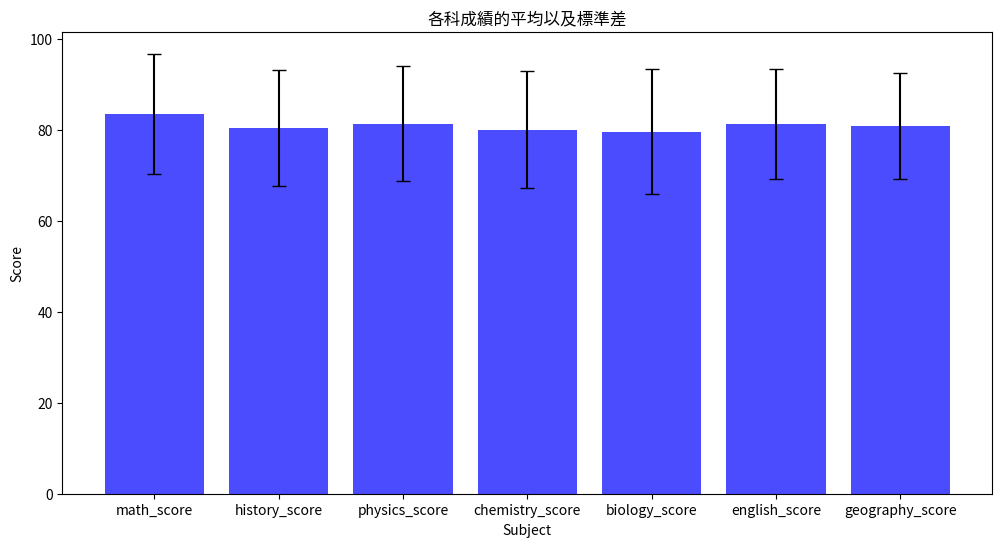

<Figure size 640x480 with 0 Axes>

In [139]:
#計算各科的平均分跟標準差
average_scores = df[['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']].mean()
std_scores = df[['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']].std()

#將計算出來的平均分跟標準差新增至df空欄位，並存成新表格
average_df = pd.DataFrame(average_scores, columns=['Average Score'])
std_df = pd.DataFrame(std_scores, columns=['Std Score'])

#設定圖表樣式
plt.figure(figsize=(12, 6))
plt.bar(average_scores.index, average_scores, yerr=std_scores, capsize=5, color='b', alpha=0.7, label='Average Score with Std Dev')

# 增加標籤
plt.xlabel('Subject')
plt.ylabel('Score')
plt.title('各科成績的平均以及標準差')

print(average_df,'\n',std_df) #顯示各科平均及標準差

plt.show()  #顯示圖表






# Q2.總成績跟每周讀書時數的相關性

總成績跟每周讀書時數的相關係數= 0.5015199798379676


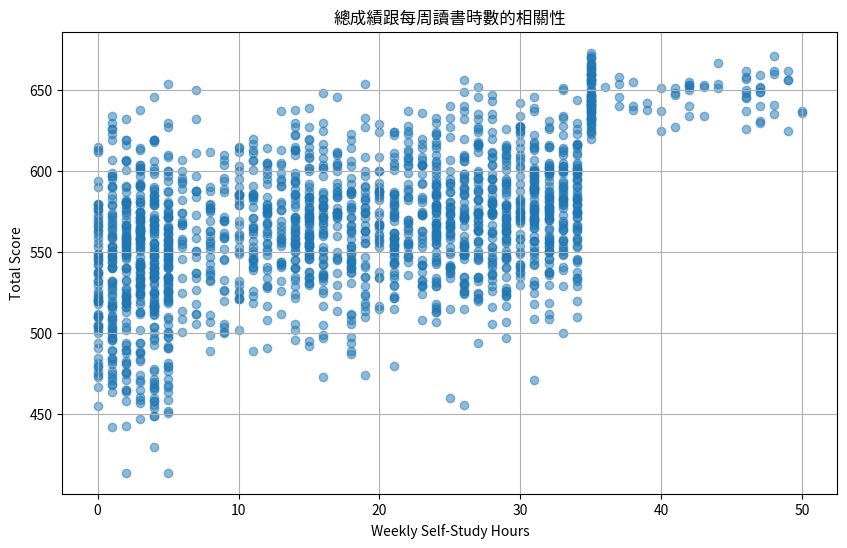

<Figure size 640x480 with 0 Axes>

In [132]:
correlation = df['weekly_self_study_hours'].corr(df[['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']].sum(axis=1)) #計算出總成績跟每周讀書時數的相關係數

df['total_score'] = df[['math_score', 'history_score', 'physics_score','chemistry_score', 'biology_score', 'english_score','geography_score']].sum(axis=1) #新增總成績欄位並輸入數值
print('總成績跟每周讀書時數的相關係數=',correlation)  #顯示相關係數

#設置圖表樣式
plt.figure(figsize=(10, 6))
plt.scatter(df['weekly_self_study_hours'], df['total_score'], alpha=0.5)

#增加標籤與隔線
plt.title('總成績跟每周讀書時數的相關性')
plt.xlabel('Weekly Self-Study Hours')
plt.ylabel('Total Score')
plt.grid(True)
#顯示圖表
plt.show()




#Q3.每個職業志向的性別比

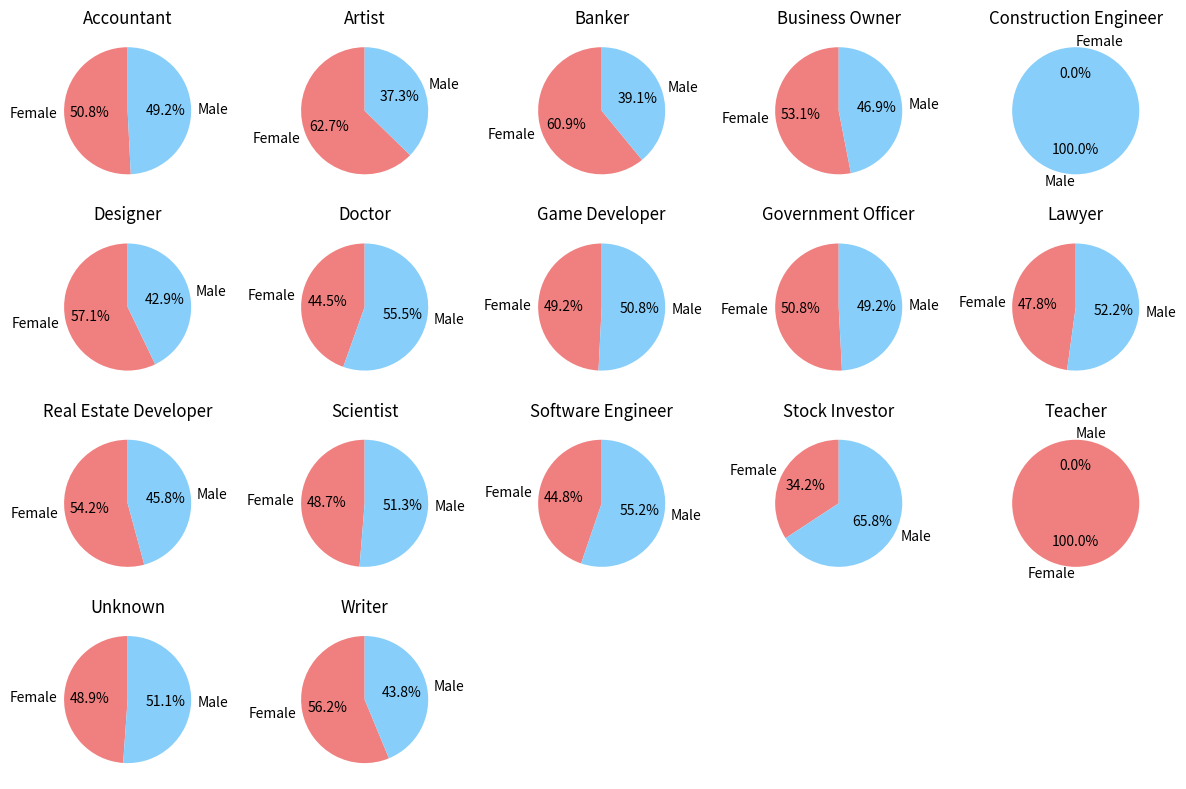

<Figure size 640x480 with 0 Axes>

In [133]:
gender_counts = df.groupby('career_aspiration')['gender'].value_counts().unstack().fillna(0)  #計算各職業中男性及女性的數量，unstack代表以職業為行、性別為列紀錄數據,fillna(0)代表缺失的數據(NaN)補0

# 計算男女的性別比
gender_counts['total'] = gender_counts['female'] + gender_counts['male']
gender_counts['female_ratio'] = gender_counts['female'] / gender_counts['total']
gender_counts['male_ratio'] = gender_counts['male'] / gender_counts['total']

#設定圖表
plt.figure(figsize=(12, 8))
colors = ['lightcoral', 'lightskyblue']

#利用for迴圈將圖表以4*5的子表顯示，標題為各職業志向，餅圖為性別占比
for i, career in enumerate(gender_counts.index):
    ratios = [gender_counts.loc[career, 'female_ratio'], gender_counts.loc[career, 'male_ratio']]
    plt.subplot(4, 5, i+1)
    plt.pie(ratios, labels=['Female', 'Male'], colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title(f'{career}')
#自動調整各圖表的間距
plt.tight_layout()
#顯示圖表
plt.show()



#Q4.總成績跟上課缺席天數的關係

每周讀書時數跟上課缺席天數的相關係數= -0.23286803525673366


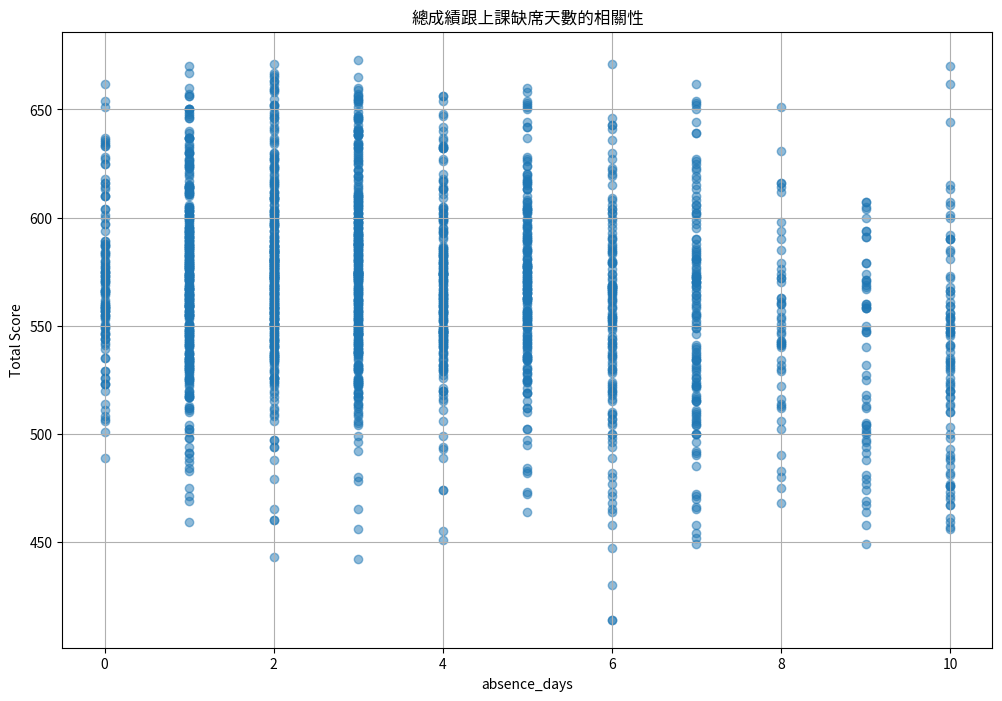

<Figure size 640x480 with 0 Axes>

In [134]:
correlation = df['absence_days'].corr(df[['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']].sum(axis=1)) #計算出總成績跟上課缺席天數的相關係數

df['total_score'] = df[['math_score', 'history_score', 'physics_score','chemistry_score', 'biology_score', 'english_score','geography_score']].sum(axis=1) #新增總成績欄位並輸入數值
print('每周讀書時數跟上課缺席天數的相關係數=',correlation)  #顯示相關係數

#設置圖表樣式
plt.figure(figsize=(12, 8))
plt.scatter(df['absence_days'], df['total_score'], alpha=0.5)

#增加標籤與隔線
plt.title('總成績跟上課缺席天數的相關性')
plt.xlabel('absence_days')
plt.ylabel('Total Score')
plt.grid(True)
#顯示圖表
plt.show()



#Q5.各職業志向的平均每周讀書時數

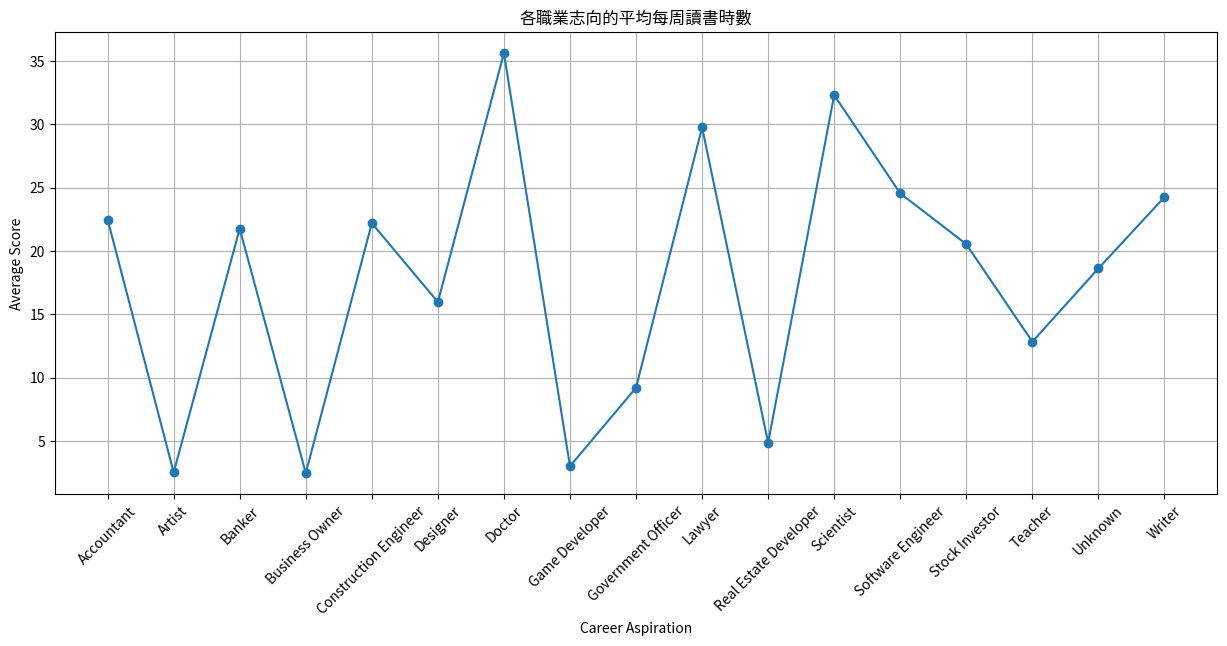

<Figure size 640x480 with 0 Axes>

In [135]:
average_study_by_career = df.groupby('career_aspiration')['weekly_self_study_hours'].mean() #計算出各職業志向的平均每周讀書時數

#設定圖表樣式
plt.figure(figsize=(15, 6))

plt.plot(average_study_by_career,marker='o')
plt.title('各職業志向的平均每周讀書時數')
plt.xlabel('Career Aspiration')
plt.ylabel('Average Score')
plt.grid(True)
plt.xticks(rotation=45)
#顯示圖表
plt.show()



#Q6.每個職業志向的各科成績平均

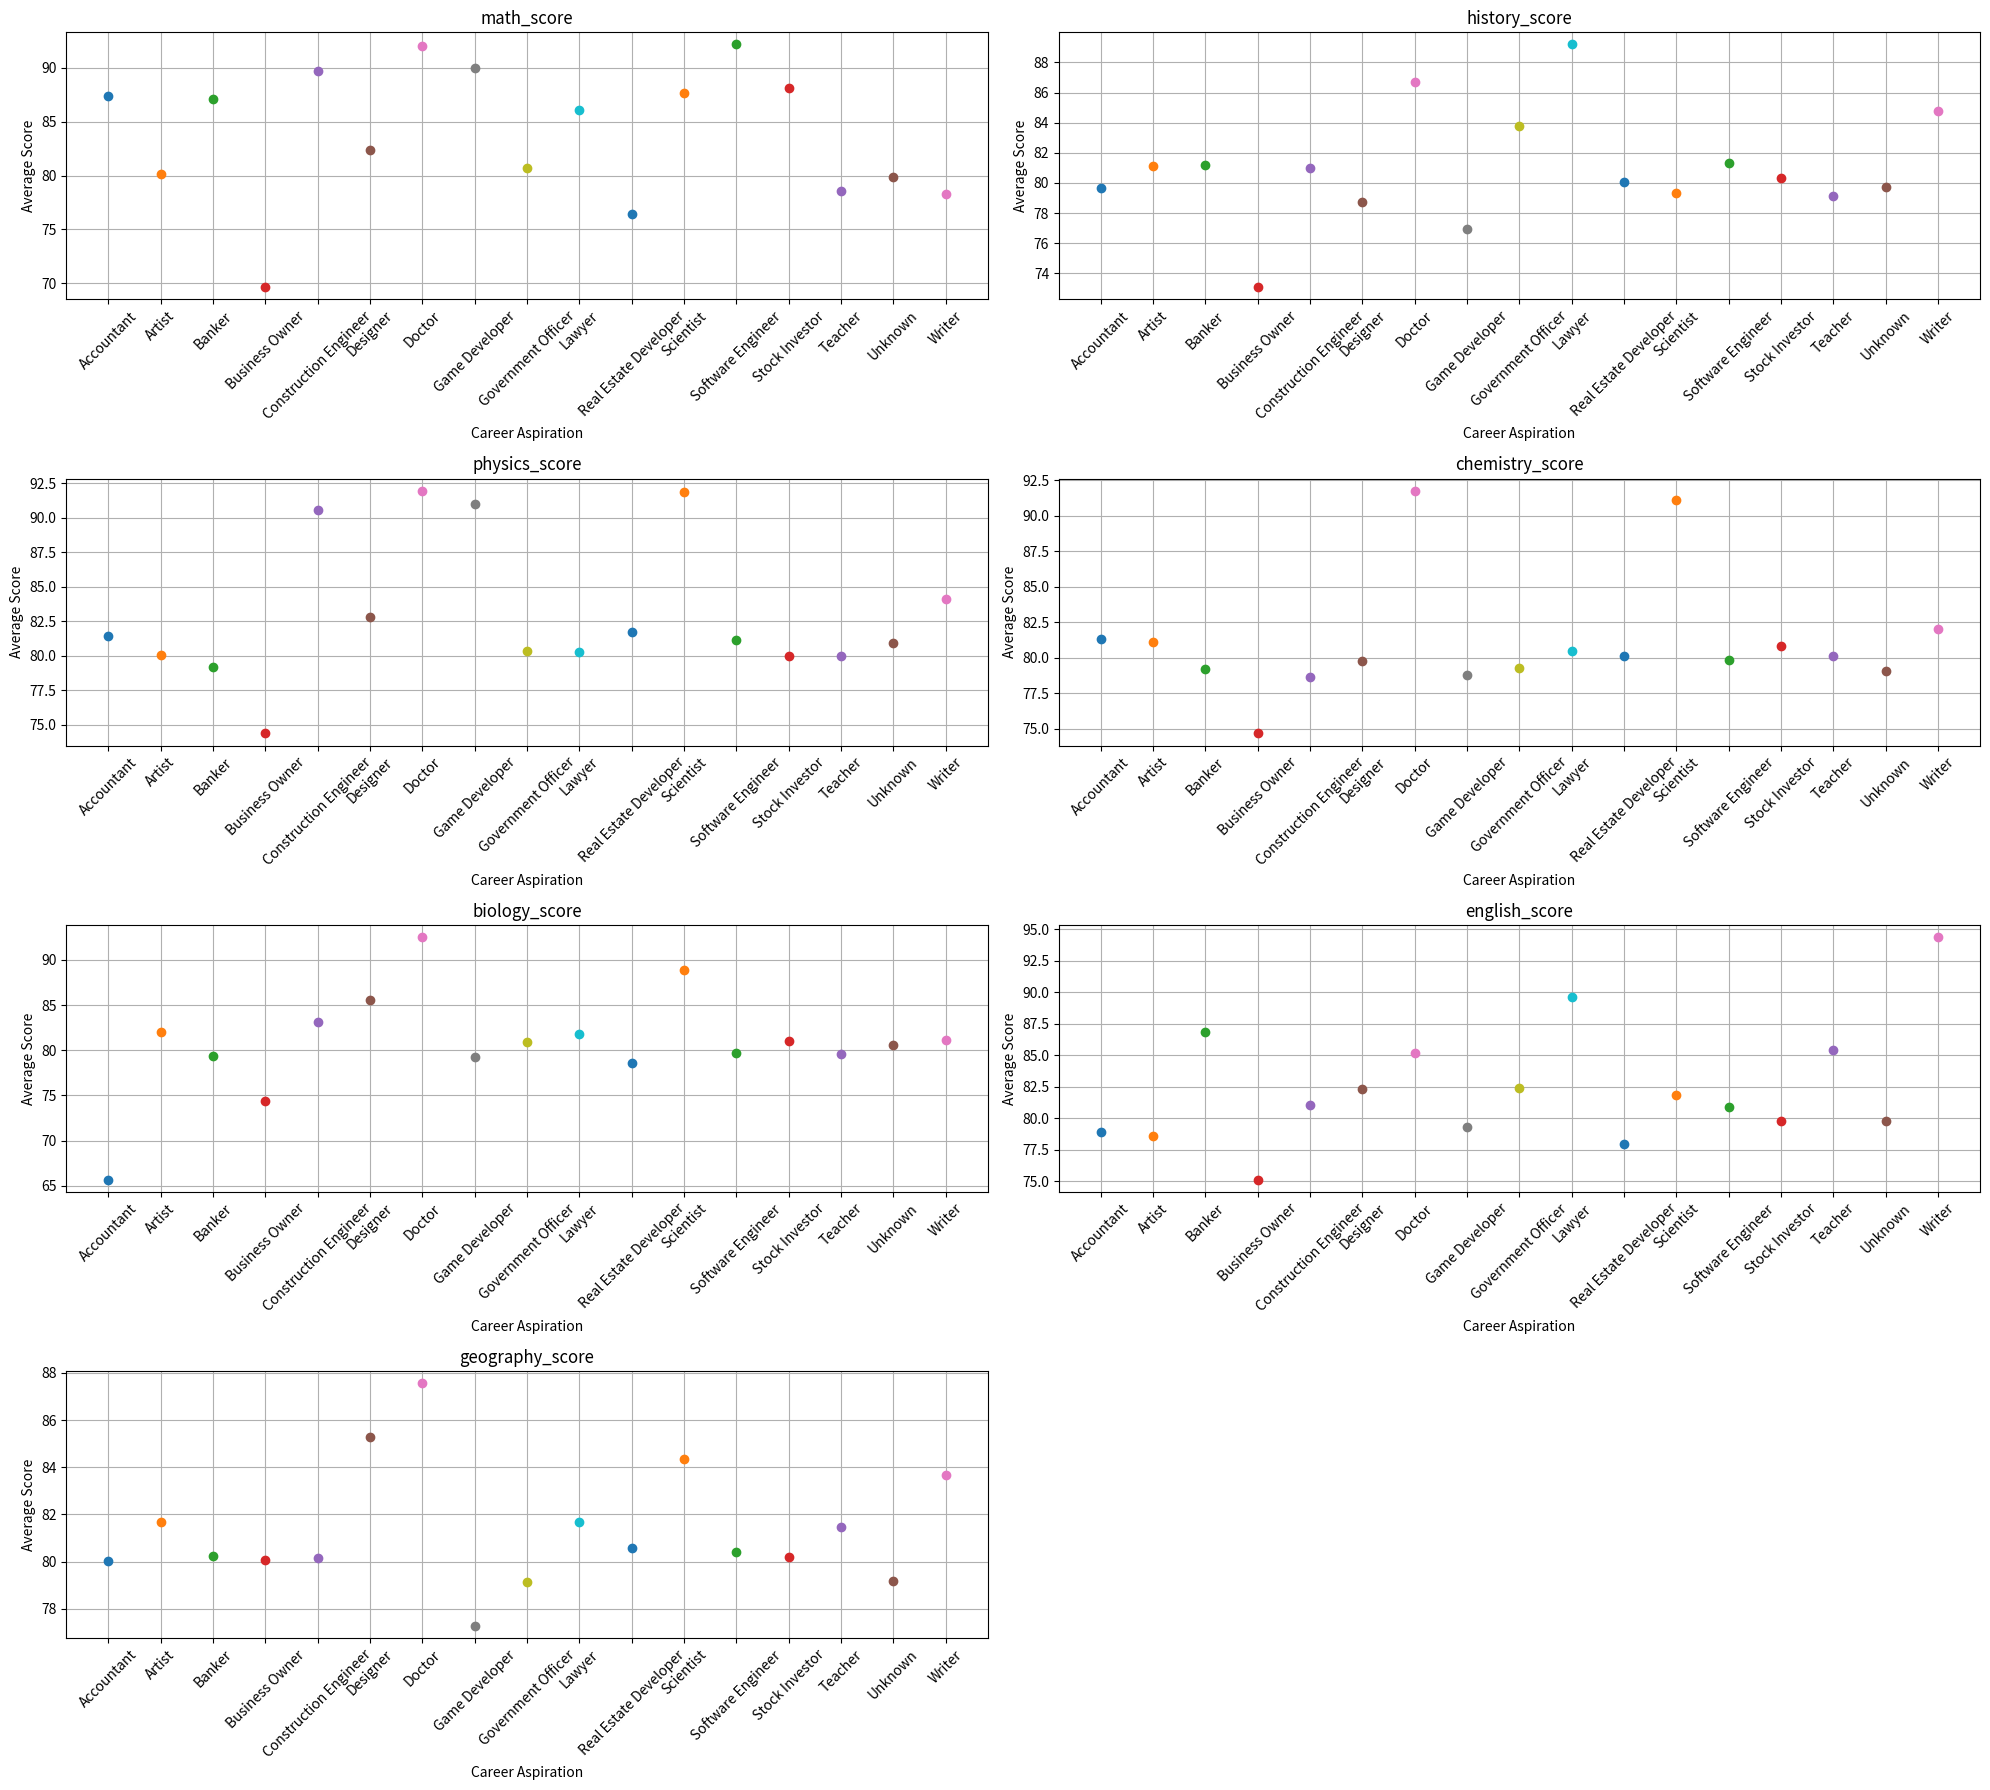

<Figure size 640x480 with 0 Axes>

In [136]:
average_scores_by_career = df.groupby('career_aspiration')[['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']].mean()

# 設定圖表大小
plt.figure(figsize=(20, 18))
#利用for迴圈將圖表以4*2的子表顯示，橫軸會各職業志向，縱軸為平均成績
for i, subject in enumerate(average_scores_by_career.columns):
    plt.subplot(4, 2, i+1)
    for career in average_scores_by_career.index:
        plt.plot([career], [average_scores_by_career.loc[career, subject]], marker='o', label=career)
    plt.title(subject)
    plt.xlabel('Career Aspiration')
    plt.ylabel('Average Score')
    plt.grid(True)
    plt.xticks(rotation=45)
#自動調整各圖表的間距
plt.tight_layout()
#顯示圖表
plt.show()

